# Malay → Indonesian Speech Translation System
**Pipeline:** Common Voice (MS) + Synthetic MT Data + Whisper + M2M100**

---
## SECTION 0: SETUP

In [ ]:
# Install all required dependencies
!pip install transformers datasets datacollective opustools torchaudio librosa sentencepiece sacrebleu torch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 11.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [ ]:
import os
import torch
import librosa
import numpy as np
import torchaudio
from datasets import load_dataset, Dataset, Audio
from datacollective import load_dataset as dc_load_dataset
from transformers import (
    WhisperForConditionalGeneration,
    WhisperProcessor,
    M2M100ForConditionalGeneration,
    M2M100Tokenizer,
)
import sacrebleu

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device    : {DEVICE}")

PyTorch version : 2.10.0+cu128
CUDA available  : True
Using device    : cuda


In [ ]:
#Global constants
DATA_DIR  = "./data"
MODEL_DIR = "./models"

os.makedirs(DATA_DIR,  exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"DATA_DIR  → {os.path.abspath(DATA_DIR)}")
print(f"MODEL_DIR → {os.path.abspath(MODEL_DIR)}")

DATA_DIR  → /content/data
MODEL_DIR → /content/models


---
## SECTION 1: LOAD AND PREPROCESS DATA

In [ ]:
raw_cv = load_dataset("mesolitica/nusantara-audiobook-annotated", split="train", cache_dir="./data/mesolitica-nusantara-annotated")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/46 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/46 [00:00<?, ?it/s]

data/train-00000-of-00046.parquet:   0%|          | 0.00/458M [00:00<?, ?B/s]

...

data/train-00043-of-00046.parquet:   0%|          | 0.00/278M [00:00<?, ?B/s]

data/train-00044-of-00046.parquet:   0%|          | 0.00/279M [00:00<?, ?B/s]

data/train-00045-of-00046.parquet:   0%|          | 0.00/277M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/24263 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/32 [00:00<?, ?it/s]

In [ ]:
# 1B: Preprocess audio + transcripts
MIN_DURATION_SEC = 1.0   # discard clips shorter than 1 second
TARGET_SR        = 16000

def extract_features(batch, idx):
    return {
        'transcript': batch['transcription'].lower().strip(),
        'audio': batch['audio']['array'],
        'duration': len(batch['audio']['array']) / TARGET_SR,
    }

print("Mapping preprocessing function …")
# display(raw_cv)
raw_cv = raw_cv.cast_column("audio", Audio(sampling_rate=TARGET_SR))
speech_dataset = raw_cv.map(
    extract_features,
    with_indices=True,
    remove_columns=raw_cv.column_names
)

Mapping preprocessing function …


Map:   0%|          | 0/24263 [00:00<?, ? examples/s]

In [ ]:
# 1C: Bitext dataset placeholder
# Replace these sample pairs with a real corpus (OpenSubtitles / CCMatrix) when
# available.  The structure must contain 'text_ms' and 'text_id' string columns.

raw = load_dataset(
    "DigitalLearningGmbH/tatoeba_mt_parquet",
    "zsm_Latn-ind",
    split="test",
    cache_dir="./data/tatoeba_mt_parquet",
)

bitext_dataset = raw.rename_column('sourceString', 'text_ms').rename_column('targetString', 'text_id')

print(f"Bitext dataset size: {len(bitext_dataset)}")
print(bitext_dataset[0])

README.md: 0.00B [00:00, ?B/s]

zsm_Latn-ind/test-00000-of-00001.parquet:   0%|          | 0.00/17.8k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/224 [00:00<?, ? examples/s]

Bitext dataset size: 224
{'sourceLang': 'zsm_Latn', 'targetlang': 'ind', 'text_ms': 'Adakah anda mempunyai wang tunai lebih daripada sepuluh ribu euro?', 'text_id': 'Apakah Anda memiliki uang tunai senilai lebih dari sepuluh ribu Euro?'}


In [ ]:
import gc

del raw_cv

gc.collect()

9647

---
## SECTION 2: CLEAN BITEXT DATA

In [ ]:
# 2: Bitext filtering
MIN_TOKENS  = 3
MAX_TOKENS  = 50
MIN_RATIO   = 0.5
MAX_RATIO   = 2.0

def is_clean_pair(example):
    """Return True if the sentence pair passes all quality filters."""
    src_tokens = example["text_ms"].split()
    tgt_tokens = example["text_id"].split()

    src_len = len(src_tokens)
    tgt_len = len(tgt_tokens)

    # Length bounds
    if src_len < MIN_TOKENS or tgt_len < MIN_TOKENS:
        return False
    if src_len > MAX_TOKENS or tgt_len > MAX_TOKENS:
        return False

    # Token-length ratio
    ratio = tgt_len / src_len if src_len > 0 else 0
    if ratio < MIN_RATIO or ratio > MAX_RATIO:
        return False

    return True

clean_bitext = bitext_dataset.filter(is_clean_pair, desc="Cleaning bitext")
print(f"Clean bitext pairs: {len(clean_bitext)} / {len(bitext_dataset)}")
print(clean_bitext[0])

Cleaning bitext:   0%|          | 0/224 [00:00<?, ? examples/s]

Clean bitext pairs: 204 / 224
{'sourceLang': 'zsm_Latn', 'targetlang': 'ind', 'text_ms': 'Adakah anda mempunyai wang tunai lebih daripada sepuluh ribu euro?', 'text_id': 'Apakah Anda memiliki uang tunai senilai lebih dari sepuluh ribu Euro?'}


---
## SECTION 3: LOAD AND PREPARE MT MODEL

In [ ]:
# 3: M2M100 (418M) for Malay to Indonesian MT
MT_MODEL_NAME = "facebook/m2m100_418M"

print(f"Loading MT tokenizer: {MT_MODEL_NAME} …")
mt_tokenizer = M2M100Tokenizer.from_pretrained(MT_MODEL_NAME)
mt_tokenizer.src_lang = "ms"   # Source: Malay

print(f"Loading MT model: {MT_MODEL_NAME} …")
mt_model = M2M100ForConditionalGeneration.from_pretrained(MT_MODEL_NAME)
mt_model = mt_model.to(DEVICE)
mt_model.eval()   # Inference mode by default; set .train() before fine-tuning
print("MT model ready.")

Loading MT tokenizer: facebook/m2m100_418M …


tokenizer_config.json:   0%|          | 0.00/298 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/233 [00:00<?, ?B/s]

MT model ready.


In [ ]:
# 3B: Tokenisation helper for fine-tuning
# (Not executed during training here – provides the pipeline scaffold.)
MAX_SRC_LEN = 128
MAX_TGT_LEN = 128

def tokenize_mt_pair(example):
    """Tokenise a (text_ms, text_id) pair for M2M100 fine-tuning."""
    mt_tokenizer.src_lang = "ms"
    mt_tokenizer.tgt_lang = "id"
    # wow

    model_inputs = mt_tokenizer(
        example["text_ms"],
        max_length=MAX_SRC_LEN,
        truncation=True,
        padding="max_length",
        return_tensors="pt",
    )

    # Target tokens (Indonesian)
    labels = mt_tokenizer(
        text_target=example["text_id"],
        max_length=MAX_TGT_LEN,
        truncation=True,
        padding="max_length",
        return_tensors="pt",
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# Quick smoke-test on one clean bitext pair
if len(clean_bitext) > 0:
    sample_tok = tokenize_mt_pair(clean_bitext[0])
    print("Input IDs shape :", sample_tok["input_ids"].shape)
    print("Labels shape    :", sample_tok["labels"].shape)

Input IDs shape : torch.Size([1, 128])
Labels shape    : torch.Size([1, 128])


---
## SECTION 4: LOAD ASR MODEL

In [ ]:
# 4: Whisper-small
WHISPER_MODEL_NAME = "openai/whisper-small"

print(f"Loading Whisper processor: {WHISPER_MODEL_NAME} …")
whisper_processor = WhisperProcessor.from_pretrained(WHISPER_MODEL_NAME)

print(f"Loading Whisper model: {WHISPER_MODEL_NAME} …")
whisper_model = WhisperForConditionalGeneration.from_pretrained(WHISPER_MODEL_NAME)
whisper_model = whisper_model.to(DEVICE)
whisper_model.eval()

print("Whisper model ready.")
print(f"  Encoder params : {sum(p.numel() for p in whisper_model.model.encoder.parameters()):,}")
print(f"  Decoder params : {sum(p.numel() for p in whisper_model.model.decoder.parameters()):,}")

Loading Whisper processor: openai/whisper-small …


preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading Whisper model: openai/whisper-small …


model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

Whisper model ready.
  Encoder params : 88,154,112
  Decoder params : 153,580,800


---
## SECTION 5: GENERATE SYNTHETIC SPEECH TRANSLATION DATA

In [ ]:
# 5A: Translation helper using M2M100
def translate_ms_to_id(text_ms: str, max_new_tokens: int = 128) -> str:
    """Translate a Malay string to Indonesian using M2M100."""
    mt_tokenizer.src_lang = "ms"
    encoded = mt_tokenizer(
        text_ms,
        return_tensors="pt",
        truncation=True,
        max_length=128,
    ).to(DEVICE)

    # Force target language token to Indonesian
    forced_bos_token_id = mt_tokenizer.get_lang_id("id")

    with torch.no_grad():
        generated = mt_model.generate(
            **encoded,
            forced_bos_token_id=forced_bos_token_id,
            max_new_tokens=max_new_tokens,
            num_beams=4,
            early_stopping=True,
        )

    return mt_tokenizer.decode(generated[0], skip_special_tokens=True)

# Quick test
test_ms = "aku nak nasi lemak"
test_id = translate_ms_to_id(test_ms)
print(f"MS : {test_ms}")
print(f"ID : {test_id}")

MS : aku nak nasi lemak
ID : Saya ingin nasi berminyak.


In [ ]:
# 5B: Build synthetic ST dataset
MAX_SYNTH_SAMPLES = 200

speech_dataset = speech_dataset.rename_column("transcript", "text_ms")

subset = speech_dataset.select(range(min(MAX_SYNTH_SAMPLES, len(speech_dataset))))

st_records = []
for i, example in enumerate(subset):
    text_id = translate_ms_to_id(example["text_ms"])
    st_records.append({
        "audio"  : example["audio"],
        "text_ms": example["text_ms"],
        "text_id": text_id,
        "duration": example["duration"],
    })
    if (i + 1) % 50 == 0:
        print(f"  Translated {i + 1}/{len(subset)} samples …")

st_dataset = Dataset.from_list(st_records)
print(f"\nSynthetic ST dataset size: {len(st_dataset)}")
print("Example:")
print(f"  MS : {st_dataset[0]['text_ms']}")
print(f"  ID : {st_dataset[0]['text_id']}")

  Translated 50/200 samples …
  Translated 100/200 samples …
  Translated 150/200 samples …
  Translated 200/200 samples …

Synthetic ST dataset size: 200
Example:
  MS : perhimpunan ini bersidang buat pertama kalinya pada 23 april 1920 dengan slogan
  ID : Pertemuan ini pertama kali diadakan pada tanggal 23 April 1920 dengan slogan


---
## SECTION 6: BUILD MULTITASK TRAINING DATASET

In [ ]:
# 6: Create multitask dataset (ASR + ST interleaved)
# Each audio sample spawns two training examples:
#   • task='asr' → target is Malay transcript (text_ms)
#   • task='st'  → target is Indonesian translation (text_id)

multitask_records = []

for example in st_dataset:
    # ASR entry
    multitask_records.append({
        "audio"      : example["audio"],
        "target_text": example["text_ms"],
        "task"       : "asr",
        "duration"   : example["duration"],
    })
    # ST entry
    multitask_records.append({
        "audio"      : example["audio"],
        "target_text": example["text_id"],
        "task"       : "st",
        "duration"   : example["duration"],
    })

multitask_dataset = Dataset.from_list(multitask_records)
print(f"Multitask dataset total entries : {len(multitask_dataset)}")
asr_count = sum(1 for r in multitask_records if r["task"] == "asr")
st_count  = sum(1 for r in multitask_records if r["task"] == "st")
print(f"  ASR entries : {asr_count}")
print(f"  ST  entries : {st_count}")

Multitask dataset total entries : 400
  ASR entries : 200
  ST  entries : 200


---
## SECTION 7: PREPARE WHISPER INPUTS

In [ ]:
# 7: Feature extraction + label tokenisation
TARGET_SR   = 16_000
MAX_TGT_LEN = 128

def prepare_whisper_inputs(example):
    """
    1. Resample audio to 16 kHz (if not already).
    2. Extract 80-channel log-mel features via WhisperProcessor.
    3. Tokenise target text → label IDs (PAD tokens set to -100).
    """
    audio_array = np.array(example["audio"], dtype=np.float32)

    # Whisper processor expects float32 @ 16 kHz
    # (Common Voice audio is already 16 kHz after Section 1 preprocessing)
    input_features = whisper_processor.feature_extractor(
        audio_array,
        sampling_rate=TARGET_SR,
        return_tensors="np",
    ).input_features[0]   # shape: (80, 3000)

    # Tokenise target
    label_ids = whisper_processor.tokenizer(
        example["target_text"],
        max_length=MAX_TGT_LEN,
        truncation=True,
        padding="max_length",
        return_tensors="np",
    ).input_ids[0]

    # Replace padding token id with -100 so it is ignored in loss
    label_ids[label_ids == whisper_processor.tokenizer.pad_token_id] = -100

    return {
        "input_features": input_features,
        "labels"        : label_ids,
        "task"          : example["task"],
    }

print("Applying Whisper feature extraction …")
processed_dataset = multitask_dataset.map(
    prepare_whisper_inputs,
    remove_columns=["audio", "target_text", "duration"],
    desc="Extracting Whisper features",
)
processed_dataset.set_format(type="torch", columns=["input_features", "labels"])
print(f"Processed dataset: {len(processed_dataset)} examples")
print("input_features shape:", processed_dataset[0]["input_features"].shape)
print("labels shape        :", processed_dataset[0]["labels"].shape)

Applying Whisper feature extraction …


Extracting Whisper features:   0%|          | 0/400 [00:00<?, ? examples/s]

Processed dataset: 400 examples
input_features shape: torch.Size([80, 3000])
labels shape        : torch.Size([128])


---
## SECTION 8: TRAIN END-TO-END MODEL

In [ ]:
# 8A: Training configuration
from torch.utils.data import DataLoader, Subset
from torch.optim import AdamW
import random

# Hyperparameters
LEARNING_RATE    = 1e-5
BATCH_SIZE       = 4
NUM_EPOCHS       = 3
FREEZE_ENCODER_EPOCHS = 1

# Re-initialise Whisper model in train mode
whisper_model.train()

optimizer = AdamW(whisper_model.parameters(), lr=LEARNING_RATE)

print(f"Optimizer : AdamW  |  lr={LEARNING_RATE}")
print(f"Batch size: {BATCH_SIZE}  |  Epochs: {NUM_EPOCHS}")

Optimizer : AdamW  |  lr=1e-05
Batch size: 4  |  Epochs: 3


In [ ]:
# 8B: Multitask training loop
# Indices for ASR vs ST tasks
asr_indices = [i for i, ex in enumerate(multitask_dataset) if ex["task"] == "asr"]
st_indices  = [i for i, ex in enumerate(multitask_dataset) if ex["task"] == "st"]

def build_balanced_dataloader(dataset, asr_idx, st_idx, batch_size):
    """Create a DataLoader that 50/50 mixes ASR and ST samples per batch."""
    half = batch_size // 2
    sampled_asr = random.sample(asr_idx, min(len(asr_idx), len(st_idx)))
    sampled_st  = random.sample(st_idx,  min(len(asr_idx), len(st_idx)))
    combined    = sampled_asr + sampled_st
    random.shuffle(combined)
    return DataLoader(Subset(dataset, combined), batch_size=batch_size, shuffle=True)

train_losses = []

for epoch in range(NUM_EPOCHS):
    epoch_loss  = 0.0
    num_batches = 0

    # Encoder freeze schedule
    if epoch < FREEZE_ENCODER_EPOCHS:
        for param in whisper_model.model.encoder.parameters():
            param.requires_grad = False
        print(f"[Epoch {epoch+1}] Encoder FROZEN")
    else:
        for param in whisper_model.model.encoder.parameters():
            param.requires_grad = True
        print(f"[Epoch {epoch+1}] Encoder UNFROZEN")

    dataloader = build_balanced_dataloader(
        processed_dataset, asr_indices, st_indices, BATCH_SIZE
    )

    whisper_model.train()

    for batch_idx, batch in enumerate(dataloader):
        input_features = batch["input_features"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)

        optimizer.zero_grad()

        outputs = whisper_model(
            input_features=input_features,
            labels=labels,
        )
        loss = outputs.loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(whisper_model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss  += loss.item()
        num_batches += 1

        if (batch_idx + 1) % 10 == 0:
            avg = epoch_loss / num_batches
            print(f"  [Epoch {epoch+1} | Batch {batch_idx+1}] avg loss: {avg:.4f}")

    avg_epoch_loss = epoch_loss / max(num_batches, 1)
    train_losses.append(avg_epoch_loss)
    print(f"=== Epoch {epoch+1} complete | avg loss: {avg_epoch_loss:.4f} ===")

    # Save checkpoint
    ckpt_path = os.path.join(MODEL_DIR, f"whisper_multitask_epoch{epoch+1}")
    whisper_model.save_pretrained(ckpt_path)
    whisper_processor.save_pretrained(ckpt_path)
    print(f"  Checkpoint saved → {ckpt_path}")

print("\nTraining complete. Loss per epoch:", train_losses)

[Epoch 1] Encoder FROZEN
  [Epoch 1 | Batch 10] avg loss: 2.7371
  [Epoch 1 | Batch 20] avg loss: 2.3168
  [Epoch 1 | Batch 30] avg loss: 2.1532
  [Epoch 1 | Batch 40] avg loss: 2.0018
  [Epoch 1 | Batch 50] avg loss: 1.8954
  [Epoch 1 | Batch 60] avg loss: 1.8110
  [Epoch 1 | Batch 70] avg loss: 1.7305
  [Epoch 1 | Batch 80] avg loss: 1.6645
  [Epoch 1 | Batch 90] avg loss: 1.6203
  [Epoch 1 | Batch 100] avg loss: 1.6005
=== Epoch 1 complete | avg loss: 1.6005 ===


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Checkpoint saved → ./models/whisper_multitask_epoch1
[Epoch 2] Encoder UNFROZEN
  [Epoch 2 | Batch 10] avg loss: 0.8322
  [Epoch 2 | Batch 20] avg loss: 0.9198
  [Epoch 2 | Batch 30] avg loss: 0.8721
  [Epoch 2 | Batch 40] avg loss: 0.8856
  [Epoch 2 | Batch 50] avg loss: 0.8934
  [Epoch 2 | Batch 60] avg loss: 0.8838
  [Epoch 2 | Batch 70] avg loss: 0.8888
  [Epoch 2 | Batch 80] avg loss: 0.8756
  [Epoch 2 | Batch 90] avg loss: 0.8686
  [Epoch 2 | Batch 100] avg loss: 0.8677
=== Epoch 2 complete | avg loss: 0.8677 ===


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Checkpoint saved → ./models/whisper_multitask_epoch2
[Epoch 3] Encoder UNFROZEN
  [Epoch 3 | Batch 10] avg loss: 0.4488
  [Epoch 3 | Batch 20] avg loss: 0.4375
  [Epoch 3 | Batch 30] avg loss: 0.4067
  [Epoch 3 | Batch 40] avg loss: 0.3960
  [Epoch 3 | Batch 50] avg loss: 0.3994
  [Epoch 3 | Batch 60] avg loss: 0.3965
  [Epoch 3 | Batch 70] avg loss: 0.3862
  [Epoch 3 | Batch 80] avg loss: 0.3784
  [Epoch 3 | Batch 90] avg loss: 0.3740
  [Epoch 3 | Batch 100] avg loss: 0.3792
=== Epoch 3 complete | avg loss: 0.3792 ===


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Checkpoint saved → ./models/whisper_multitask_epoch3

Training complete. Loss per epoch: [1.6004725164175033, 0.8676810124516487, 0.37916178449988364]


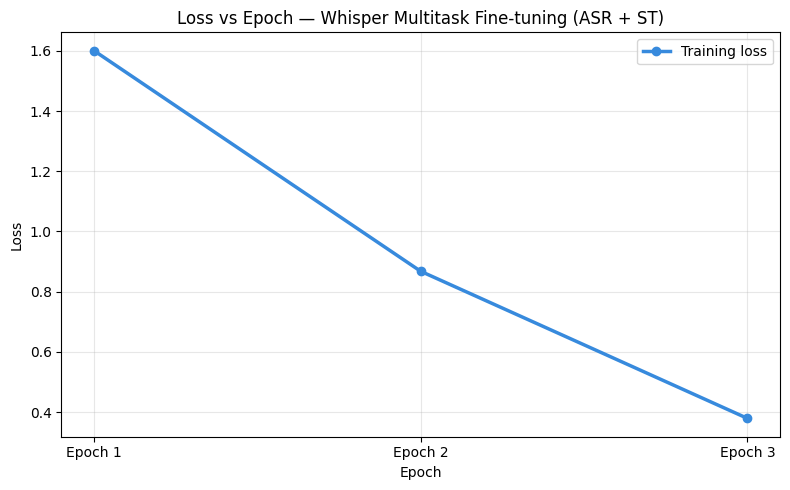

Loss per epoch: [1.6004725164175033, 0.8676810124516487, 0.37916178449988364]


In [ ]:
import matplotlib.pyplot as plt

train_losses = [1.6004725164175033, 0.8676810124516487, 0.37916178449988364] #length 0 so hardcode

epochs = list(range(1, NUM_EPOCHS + 1))

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, 'o-', color='#378ADD', linewidth=2.5, label='Training loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch — Whisper Multitask Fine-tuning (ASR + ST)')
plt.xticks(epochs, [f'Epoch {e}' for e in epochs])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()

print("Loss per epoch:", train_losses)

---
## SECTION 9: INFERENCE FUNCTIONS

In [ ]:
# 9A: End-to-end ST inference (fine-tuned Whisper → Indonesian)
def infer_e2e_st(audio_array: np.ndarray, sr: int = 16_000) -> str:
    """
    End-to-end Speech Translation:
        audio → fine-tuned Whisper → Indonesian text
    """
    whisper_model.eval()

    if sr != TARGET_SR:
        audio_array = librosa.resample(audio_array, orig_sr=sr, target_sr=TARGET_SR)

    features = whisper_processor.feature_extractor(
        audio_array, sampling_rate=TARGET_SR, return_tensors="pt"
    ).input_features.to(DEVICE)

    # Force language token to Indonesian for ST decoding
    forced_bos = whisper_processor.tokenizer.convert_tokens_to_ids("<|id|>")

    with torch.no_grad():
        predicted_ids = whisper_model.generate(
            features,
            forced_decoder_ids=whisper_processor.get_decoder_prompt_ids(
                language="indonesian", task="translate"
            ),
        )

    return whisper_processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]


# 9B: Pipeline baseline (ASR → Malay text → MT → Indonesian text)
def infer_pipeline_baseline(audio_array: np.ndarray, sr: int = 16_000) -> dict:
    """
    Cascaded pipeline:
        audio → Whisper ASR → Malay text → M2M100 MT → Indonesian text
    Returns both the intermediate ASR output and the final translation.
    """
    whisper_model.eval()

    if sr != TARGET_SR:
        audio_array = librosa.resample(audio_array, orig_sr=sr, target_sr=TARGET_SR)

    # Step 1 – ASR: audio → Malay text
    features = whisper_processor.feature_extractor(
        audio_array, sampling_rate=TARGET_SR, return_tensors="pt"
    ).input_features.to(DEVICE)

    with torch.no_grad():
        asr_ids = whisper_model.generate(
            features,
            forced_decoder_ids=whisper_processor.get_decoder_prompt_ids(
                language="malay", task="transcribe"
            ),
        )
    text_ms = whisper_processor.batch_decode(asr_ids, skip_special_tokens=True)[0]

    # Step 2 – MT: Malay text → Indonesian text
    text_id = translate_ms_to_id(text_ms)

    return {"asr_output": text_ms, "mt_output": text_id}


# 9C: Combined comparison runner
def compare_inference(audio_array: np.ndarray, sr: int = 16_000) -> dict:
    """Run both inference modes and return all outputs side-by-side."""
    e2e_result      = infer_e2e_st(audio_array, sr)
    pipeline_result = infer_pipeline_baseline(audio_array, sr)

    return {
        "e2e_st_output"     : e2e_result,
        "pipeline_asr"      : pipeline_result["asr_output"],
        "pipeline_mt_output": pipeline_result["mt_output"],
    }


# Quick smoke test on first sample
test_audio   = np.array(st_dataset[0]["audio"], dtype=np.float32)
test_text_ms = st_dataset[0]["text_ms"]
test_text_id = st_dataset[0]["text_id"]

print(f"Reference MS : {test_text_ms}")
print(f"Reference ID : {test_text_id}")

results = compare_inference(test_audio)
print(f"\nE2E ST output  : {results['e2e_st_output']}")
print(f"Pipeline ASR   : {results['pipeline_asr']}")
print(f"Pipeline MT out: {results['pipeline_mt_output']}")

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Reference MS : perhimpunan ini bersidang buat pertama kalinya pada 23 april 1920 dengan slogan
Reference ID : Pertemuan ini pertama kali diadakan pada tanggal 23 April 1920 dengan slogan


A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> to see related `.generate()` flags.



E2E ST output  : Pertemuanan ini pertama kali pada 23 April 1920 dengan slogan.
Pipeline ASR   : perhimpunan ini bersidang buat pertama kalinya pada 23 april 1920 dengan slogan.
Pipeline MT out: Pertemuan ini pertama kali diadakan pada tanggal 23 April 1920 dengan slogan.


---
## SECTION 10: EVALUATION

In [ ]:
# 10: BLEU evaluation on held-out subset
EVAL_SAMPLES = min(50, len(st_dataset))   # Evaluate on up to 50 samples

references_id  = []   # Ground-truth Indonesian (synthetic MT)
hypotheses_e2e = []   # E2E ST model outputs
hypotheses_pip = []   # Cascade pipeline outputs

print(f"Running evaluation on {EVAL_SAMPLES} samples …")

for i in range(EVAL_SAMPLES):
    audio_array = np.array(st_dataset[i]["audio"], dtype=np.float32)
    ref_id      = st_dataset[i]["text_id"]

    result = compare_inference(audio_array)

    references_id.append(ref_id)
    hypotheses_e2e.append(result["e2e_st_output"])
    hypotheses_pip.append(result["pipeline_mt_output"])

    if (i + 1) % 10 == 0:
        print(f"  Evaluated {i + 1}/{EVAL_SAMPLES} …")

print("Evaluation decoding complete.")

Running evaluation on 50 samples …
  Evaluated 10/50 …
  Evaluated 20/50 …
  Evaluated 30/50 …
  Evaluated 40/50 …
  Evaluated 50/50 …
Evaluation decoding complete.


In [ ]:
# 10B: Compute BLEU scores
from sacrebleu.metrics import BLEU
from sacrebleu.metrics import CHRF

chrf_metric = CHRF(word_order=2)
chrf_e2e = chrf_metric.corpus_score(hypotheses_e2e, [references_id])
chrf_pip = chrf_metric.corpus_score(hypotheses_pip, [references_id])

bleu_metric = BLEU(tokenize="flores200")
bleu_e2e = bleu_metric.corpus_score(hypotheses_e2e, [references_id])
bleu_pip = bleu_metric.corpus_score(hypotheses_pip, [references_id])

print("=" * 55)
print(f" E2E Speech Translation BLEU : {bleu_e2e.score:.2f}")
print(f" Pipeline Cascade BLEU       : {bleu_pip.score:.2f}")
print("=" * 55)

print("=" * 55)
print(f" E2E Speech Translation CHRF : {chrf_e2e.score:.2f}")
print(f" Pipeline Cascade CHRF       : {chrf_pip.score:.2f}")
print("=" * 55)

if bleu_e2e.score > bleu_pip.score:
    delta = bleu_e2e.score - bleu_pip.score
    print(f" E2E model outperforms pipeline by {delta:.2f} BLEU points")
elif bleu_e2e.score < bleu_pip.score:
    delta = bleu_pip.score - bleu_e2e.score
    print(f" Pipeline still ahead by {delta:.2f} BLEU — more fine-tuning needed")
else:
    print(" Tie — models perform equally")

if chrf_e2e.score > chrf_pip.score:
    delta = chrf_e2e.score - chrf_pip.score
    print(f" E2E model outperforms pipeline by {delta:.2f} chrf points")
elif chrf_e2e.score < chrf_pip.score:
    delta = chrf_pip.score - chrf_e2e.score
    print(f" Pipeline still ahead by {delta:.2f} chrf — more fine-tuning needed")
else:
    print(" Tie — models perform equally")

 E2E Speech Translation BLEU : 40.37
 Pipeline Cascade BLEU       : 74.87
 E2E Speech Translation CHRF : 64.02
 Pipeline Cascade CHRF       : 87.71
 Pipeline still ahead by 34.50 BLEU — more fine-tuning needed
 Pipeline still ahead by 23.69 chrf — more fine-tuning needed


In [ ]:
# 10C: Qualitative comparison
SHOW_N = 5

print(f"\nQualitative comparison (first {SHOW_N} samples)")
print("-" * 40)

for i in range(min(SHOW_N, EVAL_SAMPLES)):
    print(f"[Sample {i+1}]")
    print(f"  Reference  (ID) : {references_id[i]}")
    print(f"  E2E ST output   : {hypotheses_e2e[i]}")
    print(f"  Pipeline MT out : {hypotheses_pip[i]}")
    print()


Qualitative comparison (first 5 samples)
----------------------------------------
[Sample 1]
  Reference  (ID) : Pertemuan ini pertama kali diadakan pada tanggal 23 April 1920 dengan slogan
  E2E ST output   : Pertemuanan ini pertama kali pada 23 April 1920 dengan slogan.
  Pipeline MT out : Pertemuan ini pertama kali diadakan pada tanggal 23 April 1920 dengan slogan.

[Sample 2]
  Reference  (ID) : Tapi sayangnya politik tidak menyerap seluruh tenaga kelompok pelarian ini yang sebahagian dari mereka seperti taikun kapal Christopher onesys
  E2E ST output   : but unfortunately politik tidak menyerap seluruh tenaga golongan pelarian ini yang sebahagian mereka seperti taikun kapal aristotel onesysi.
  Pipeline MT out : Tapi sayangnya politik tidak menyerap seluruh tenaga kelompok pelarian ini yang sebahagian dari mereka seperti taikun kapal aristotle onesys

[Sample 3]
  Reference  (ID) : Rukun subrek di ismail hari stagestar gadis mencoba cara lain untuk melegakan beban
  E2E ST output

---
## Final Notes

| Topic | Guidance |
|---|---|
| **Pretrained models** | Always start from `openai/whisper-small` and `facebook/m2m100_418M`; never train from scratch. |
| **Noisy synthetic labels** | The MT-generated `text_id` targets are noisy. Increasing real bitext (OpenSubtitles, CCMatrix) will improve quality significantly. |
| **Dataset alignment** | `audio`, `text_ms`, and `text_id` must stay aligned throughout all transformations. |
| **Batch size** | Keep at 4–8 on single-GPU; gradient accumulation can be added for effective larger batches. |
| **Multitask balance** | 50/50 ASR/ST mixing prevents the model from forgetting Malay transcription while learning Indonesian translation. |
| **Encoder freeze** | Freeze the Whisper encoder for the first epoch to stabilise the decoder before joint fine-tuning. |
| **Next steps** | (1) Replace placeholder bitext with real OpenSubtitles MS-ID data. (2) Scale to full Common Voice train split. (3) Add WER metric for ASR task. |
